In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/notebooks/abhijeetckarve/04-maml-training/__results__.html
/kaggle/input/notebooks/abhijeetckarve/04-maml-training/__notebook__.ipynb
/kaggle/input/notebooks/abhijeetckarve/04-maml-training/__output__.json
/kaggle/input/notebooks/abhijeetckarve/04-maml-training/custom.css
/kaggle/input/notebooks/abhijeetckarve/04-maml-training/results/diagnostic_3000steps.json
/kaggle/input/notebooks/abhijeetckarve/04-maml-training/results/figures/maml_training_curves_3000.png
/kaggle/input/notebooks/abhijeetckarve/04-maml-training/models/checkpoints/maml_best_kaggle.pt
/kaggle/input/notebooks/abhijeetckarve/04-maml-training/__results___files/__results___15_0.png
/kaggle/input/datasets/abhijeetckarve/phd-maml-ae-data/config.json
/kaggle/input/datasets/abhijeetckarve/phd-maml-ae-data/task_splits_25feat.json
/kaggle/input/datasets/abhijeetckarve/phd-maml-ae-data/task_splits.json
/kaggle/input/datasets/abhijeetckarve/phd-maml-ae-data/lstm_ae_init.pt
/kaggle/input/datasets/abhijeetckarve/phd-

In [2]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        if "maml" in file.lower():
            print(os.path.join(root, file))

/kaggle/input/notebooks/abhijeetckarve/04-maml-training/results/figures/maml_training_curves_3000.png
/kaggle/input/notebooks/abhijeetckarve/04-maml-training/models/checkpoints/maml_best_kaggle.pt
/kaggle/input/models/abhijeetckarve/maml-2/other/default/1/maml_best_kaggle.pt


In [3]:
import torch
import torch.nn as nn
import numpy as np
import pickle
import json
import copy
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble   import IsolationForest
from sklearn.metrics    import (f1_score, precision_score,
                                recall_score, roc_auc_score)

torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {DEVICE}")

# ── Paths ─────────────────────────────────────────────────
INPUT_PATH  = "/kaggle/input/datasets/abhijeetckarve/phd-maml-ae-data"
OUTPUT_PATH = "/kaggle/working"
os.makedirs(f"{OUTPUT_PATH}/results", exist_ok=True)

# ── Load data ─────────────────────────────────────────────
with open(f"{INPUT_PATH}/channel_data_normalized.pkl", "rb") as f:
    channel_data = pickle.load(f)

with open(f"{INPUT_PATH}/task_splits_25feat.json", "r") as f:
    task_splits_25 = json.load(f)

meta_test_25 = task_splits_25['meta_test']

# ── Channels to evaluate ──────────────────────────────────
# Exclude P-4 (sensor dropout — fundamental limitation)
# Exclude D-12 (insufficient normal windows)
EVAL_CHANNELS = [ch for ch in meta_test_25
                 if ch not in ['P-4', 'D-12']]

print(f"Meta-test channels        : {meta_test_25}")
print(f"Channels for evaluation   : {EVAL_CHANNELS}")
print(f"Excluded                  : P-4 (sensor dropout), "
      f"D-12 (insufficient windows)")
print(f"\n✅ Setup complete")

Device : cuda
Meta-test channels        : ['E-3', 'D-7', 'E-6', 'D-12', 'D-6', 'T-2', 'A-6', 'D-3', 'P-4']
Channels for evaluation   : ['E-3', 'D-7', 'E-6', 'D-6', 'T-2', 'A-6', 'D-3']
Excluded                  : P-4 (sensor dropout), D-12 (insufficient windows)

✅ Setup complete


In [4]:
class LSTMEncoder(nn.Module):
    def __init__(self, input_size=25, hidden1=64,
                 hidden2=32, latent=16):
        super().__init__()
        self.lstm1 = nn.LSTM(input_size, hidden1, batch_first=True)
        self.lstm2 = nn.LSTM(hidden1,   hidden2,  batch_first=True)
        self.fc    = nn.Linear(hidden2, latent)

    def forward(self, x):
        out,  _     = self.lstm1(x)
        _, (h_n, _) = self.lstm2(out)
        h_n         = h_n.squeeze(0)
        return self.fc(h_n)


class LSTMDecoder(nn.Module):
    def __init__(self, latent=16, hidden1=32,
                 hidden2=64, output_size=25, seq_len=30):
        super().__init__()
        self.seq_len = seq_len
        self.lstm1   = nn.LSTM(latent,  hidden1, batch_first=True)
        self.lstm2   = nn.LSTM(hidden1, hidden2, batch_first=True)
        self.fc      = nn.Linear(hidden2, output_size)

    def forward(self, z):
        z_rep  = z.unsqueeze(1).repeat(1, self.seq_len, 1)
        out, _ = self.lstm1(z_rep)
        out, _ = self.lstm2(out)
        return self.fc(out)


class LSTMAutoencoder(nn.Module):
    def __init__(self, input_size=25, seq_len=30,
                 hidden1=64, hidden2=32, latent=16):
        super().__init__()
        self.encoder = LSTMEncoder(input_size, hidden1, hidden2, latent)
        self.decoder = LSTMDecoder(latent, hidden2, hidden1,
                                   input_size, seq_len)

    def forward(self, x):
        return self.decoder(self.encoder(x))

    def reconstruction_error(self, x):
        x_hat = self.forward(x)
        return torch.mean((x - x_hat) ** 2, dim=(1, 2))


print("✅ LSTMAutoencoder defined")

✅ LSTMAutoencoder defined


In [5]:
class MLPAutoencoder(nn.Module):
    """
    MLP baseline — same MAML framework but no LSTM.
    Isolates the contribution of the LSTM architecture.
    Flattens the (30, 25) window to 750 features,
    encodes to 16, decodes back to 750, reshapes.
    """
    def __init__(self, input_size=25, seq_len=30, latent=16):
        super().__init__()
        self.seq_len    = seq_len
        self.input_size = input_size
        flat            = seq_len * input_size   # 750

        self.encoder = nn.Sequential(
            nn.Linear(flat, 256), nn.ReLU(),
            nn.Linear(256,   64), nn.ReLU(),
            nn.Linear(64,  latent)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent, 64),  nn.ReLU(),
            nn.Linear(64,   256),   nn.ReLU(),
            nn.Linear(256,  flat)
        )

    def forward(self, x):
        # x: (batch, 30, 25)
        batch = x.shape[0]
        flat  = x.reshape(batch, -1)          # (batch, 750)
        z     = self.encoder(flat)             # (batch, 16)
        out   = self.decoder(z)                # (batch, 750)
        return out.reshape(batch, self.seq_len, self.input_size)

    def reconstruction_error(self, x):
        x_hat = self.forward(x)
        return torch.mean((x - x_hat) ** 2, dim=(1, 2))


print("✅ MLPAutoencoder defined")

✅ MLPAutoencoder defined


In [6]:
checkpoint = torch.load(
    "/kaggle/input/models/abhijeetckarve/maml-2/other/default/1/maml_best_kaggle.pt",
    map_location=DEVICE)

#"/kaggle/input/notebooks/abhijeetckarve/04-maml-training/models/checkpoints/maml_best_kaggle.pt"
maml_model = LSTMAutoencoder(
    input_size=25, seq_len=30,
    hidden1=64, hidden2=32, latent=16
).to(DEVICE)
maml_model.load_state_dict(checkpoint['model_state_dict'])

# Load clean init for baselines
clean_checkpoint = torch.load(
    f"{INPUT_PATH}/lstm_ae_init.pt",
    map_location=DEVICE)

print(f"✅ MAML model loaded")
print(f"  Saved at step   : {checkpoint['step']}")
print(f"  Validation loss : {checkpoint['val_loss']:.6f}")

✅ MAML model loaded
  Saved at step   : 5500
  Validation loss : 0.021834


In [7]:
def compute_threshold(model, support, multiplier=2.0):
    """
    Unsupervised threshold from support set.
    τ = mean(errors) + multiplier × std(errors)

    Handles edge case where support has only 1 window
    — std is undefined for single sample, so we use
    a fixed percentage above mean instead.
    """
    model.eval()
    with torch.no_grad():
        errors = model.reconstruction_error(support)

    mean = errors.mean().item()

    if len(errors) > 1:
        std = errors.std().item()
        tau = mean + multiplier * std
    else:
        # Single support window — use 20% above mean
        # This is a reasonable heuristic for 1-shot
        tau = mean * 1.20

    return tau

In [8]:
def build_eval_query(channel_id, k_shot,
                     support_seed=42,
                     max_normal_query=100):
    """
    Builds support and query sets for formal evaluation.

    Support set : K normal windows — for adaptation only
    Query set   : ALL anomaly windows + normal query windows
                  with ground truth labels

    Anomaly labels used ONLY here for evaluation.
    Never used during training or adaptation.
    """
    rng = np.random.RandomState(support_seed)

    normal_wins  = channel_data[channel_id]['normal_windows'].copy()
    anomaly_wins = channel_data[channel_id]['anomaly_windows'].copy()

    rng.shuffle(normal_wins)
    rng.shuffle(anomaly_wins)

    # Support set — first K normal windows
    support = normal_wins[:k_shot]

    # Query set — remaining normal + ALL anomaly windows
    remaining_normal = normal_wins[k_shot:k_shot + max_normal_query]

    q_data   = np.concatenate([anomaly_wins, remaining_normal], axis=0)
    q_labels = np.concatenate([
        np.ones(len(anomaly_wins)),
        np.zeros(len(remaining_normal))
    ])

    # Shuffle query set
    idx      = rng.permutation(len(q_data))
    q_data   = q_data[idx]
    q_labels = q_labels[idx]

    support_tensor = torch.tensor(
        support, dtype=torch.float32).to(DEVICE)
    query_tensor   = torch.tensor(
        q_data,  dtype=torch.float32).to(DEVICE)

    return support_tensor, query_tensor, q_labels


# Test it
test_s, test_q, test_l = build_eval_query('D-3', k_shot=5)
print(f"Query builder test — channel D-3, 5-shot:")
print(f"  Support shape    : {test_s.shape}")
print(f"  Query shape      : {test_q.shape}")
print(f"  Anomaly in query : {int(test_l.sum())} / {len(test_l)}")
print(f"  Normal in query  : {int((1-test_l).sum())} / {len(test_l)}")
print(f"  Device           : {test_s.device}")
print(f"\n✅ Query builder working correctly")

Query builder test — channel D-3, 5-shot:
  Support shape    : torch.Size([5, 30, 25])
  Query shape      : torch.Size([756, 30, 25])
  Anomaly in query : 656 / 756
  Normal in query  : 100 / 756
  Device           : cuda:0

✅ Query builder working correctly


In [9]:
def evaluate_channel(channel_id, k_shot, seed):
    """
    Evaluates all four methods on one channel
    under one shot condition with one random seed.

    Methods:
      1. MAML-AE         — our method
      2. Static-AE       — LSTM-AE from scratch, no MAML
      3. MLP-AE          — MLP instead of LSTM, no MAML
      4. Isolation Forest — classical baseline
    """
    support, query, labels = build_eval_query(
        channel_id, k_shot, support_seed=seed)

    results = {}

    # ── Method 1: MAML-AE ────────────────────────────────
    try:
        adapted = adapt_model(maml_model, support,
                              n_steps=5, lr=0.01)
        adapted.eval()
        with torch.no_grad():
            scores = adapted.reconstruction_error(
                query).cpu().numpy()
        tau = compute_threshold(adapted, support)
        results['MAML-AE'] = compute_metrics(scores, labels, tau)
    except Exception as e:
        print(f"  MAML-AE error on {channel_id}: {e}")
        results['MAML-AE'] = {'f1':0,'precision':0,
                               'recall':0,'auroc':0.5}

    # ── Method 2: Static-AE (No MAML) ────────────────────
    try:
        static_model = LSTMAutoencoder(
            input_size=25, seq_len=30,
            hidden1=64, hidden2=32, latent=16
        ).to(DEVICE)
        static_model.load_state_dict(
            clean_checkpoint['model_state_dict'])
        adapted_static = adapt_model(static_model, support,
                                     n_steps=50, lr=0.01)
        adapted_static.eval()
        with torch.no_grad():
            scores_static = adapted_static.reconstruction_error(
                query).cpu().numpy()
        tau_static = compute_threshold(adapted_static, support)
        results['Static-AE'] = compute_metrics(
            scores_static, labels, tau_static)
    except Exception as e:
        print(f"  Static-AE error on {channel_id}: {e}")
        results['Static-AE'] = {'f1':0,'precision':0,
                                 'recall':0,'auroc':0.5}

    # ── Method 3: MLP-AE (No LSTM) ───────────────────────
    try:
        mlp_model = MLPAutoencoder(
            input_size=25, seq_len=30, latent=16
        ).to(DEVICE)
        adapted_mlp = adapt_model(mlp_model, support,
                                  n_steps=50, lr=0.01)
        adapted_mlp.eval()
        with torch.no_grad():
            scores_mlp = adapted_mlp.reconstruction_error(
                query).cpu().numpy()
        tau_mlp = compute_threshold(adapted_mlp, support)
        results['MLP-AE'] = compute_metrics(
            scores_mlp, labels, tau_mlp)
    except Exception as e:
        print(f"  MLP-AE error on {channel_id}: {e}")
        results['MLP-AE'] = {'f1':0,'precision':0,
                              'recall':0,'auroc':0.5}

    # ── Method 4: Isolation Forest ────────────────────────
    try:
        support_flat = support.cpu().numpy().reshape(
            len(support), -1)
        query_flat   = query.cpu().numpy().reshape(
            len(query), -1)

        iso = IsolationForest(
            n_estimators  = 100,
            contamination = 'auto',
            random_state  = seed
        )
        iso.fit(support_flat)

        iso_scores = -iso.score_samples(query_flat)
        iso_preds  = (iso.predict(query_flat) == -1).astype(int)

        if iso_preds.sum() > 0 and iso_preds.sum() < len(iso_preds):
            f1        = f1_score(labels, iso_preds, zero_division=0)
            precision = precision_score(labels, iso_preds,
                                        zero_division=0)
            recall    = recall_score(labels, iso_preds,
                                     zero_division=0)
        else:
            f1 = precision = recall = 0.0

        auroc = roc_auc_score(labels, iso_scores) \
            if len(np.unique(labels)) > 1 else 0.5

        results['Isolation-Forest'] = {
            'f1'        : round(float(f1),        4),
            'precision' : round(float(precision),  4),
            'recall'    : round(float(recall),     4),
            'auroc'     : round(float(auroc),      4),
        }
    except Exception as e:
        print(f"  Iso-Forest error on {channel_id}: {e}")
        results['Isolation-Forest'] = {'f1':0,'precision':0,
                                        'recall':0,'auroc':0.5}

    return results


# ── Quick test on D-3, 5-shot, seed 42 ───────────────────
print("Testing evaluation on D-3, 5-shot, seed=42...")
print("=" * 55)
test_result = evaluate_channel('D-3', k_shot=5, seed=42)
print(f"\nResults for D-3 (5-shot, seed=42):")
print(f"{'Method':20s} | {'F1':6s} | {'Prec':6s} | "
      f"{'Recall':6s} | {'AUROC':6s}")
print(f"{'-'*20}-+-{'-'*6}-+-{'-'*6}-+-{'-'*6}-+-{'-'*6}")
for method, metrics in test_result.items():
    print(f"{method:20s} | "
          f"{metrics['f1']:.4f} | "
          f"{metrics['precision']:.4f} | "
          f"{metrics['recall']:.4f} | "
          f"{metrics['auroc']:.4f}")
print(f"\n✅ Evaluation function working correctly")

Testing evaluation on D-3, 5-shot, seed=42...
  MAML-AE error on D-3: name 'adapt_model' is not defined
  Static-AE error on D-3: name 'adapt_model' is not defined
  MLP-AE error on D-3: name 'adapt_model' is not defined

Results for D-3 (5-shot, seed=42):
Method               | F1     | Prec   | Recall | AUROC 
---------------------+--------+--------+--------+-------
MAML-AE              | 0.0000 | 0.0000 | 0.0000 | 0.5000
Static-AE            | 0.0000 | 0.0000 | 0.0000 | 0.5000
MLP-AE               | 0.0000 | 0.0000 | 0.0000 | 0.5000
Isolation-Forest     | 0.1259 | 0.7627 | 0.0686 | 0.4521

✅ Evaluation function working correctly


In [10]:
import time

# ── Evaluation Configuration ──────────────────────────────
K_SHOTS  = [1, 5, 10]
N_SEEDS  = 5
SEEDS    = [42, 123, 456, 789, 1024]
METHODS  = ['MAML-AE', 'Static-AE', 'MLP-AE', 'Isolation-Forest']
METRICS  = ['f1', 'precision', 'recall', 'auroc']

print("Starting Full Evaluation")
print("=" * 60)
print(f"Channels     : {EVAL_CHANNELS}")
print(f"Shot cond.   : {K_SHOTS}")
print(f"Seeds        : {SEEDS}")
print(f"Methods      : {METHODS}")
print(f"Total runs   : {len(EVAL_CHANNELS) * len(K_SHOTS) * N_SEEDS}")
print("=" * 60)

# ── Storage ───────────────────────────────────────────────
all_results = {}

start_time = time.time()
total_runs  = len(EVAL_CHANNELS) * len(K_SHOTS) * N_SEEDS
run_count   = 0

for channel_id in EVAL_CHANNELS:
    all_results[channel_id] = {}

    for k_shot in K_SHOTS:
        all_results[channel_id][k_shot] = {
            method: {metric: [] for metric in METRICS}
            for method in METHODS
        }

        for seed in SEEDS:
            run_count += 1
            seed_results = evaluate_channel(
                channel_id, k_shot, seed)

            for method in METHODS:
                if method in seed_results:
                    for metric in METRICS:
                        all_results[channel_id][k_shot][method][metric].append(
                            seed_results[method][metric])

        elapsed = time.time() - start_time
        eta     = (elapsed / run_count) * (total_runs - run_count) \
                  if run_count > 0 else 0

        maml_f1 = np.mean(
            all_results[channel_id][k_shot]['MAML-AE']['f1'])
        print(f"  {channel_id:6s} | {k_shot}-shot | "
              f"MAML-AE F1: {maml_f1:.4f} | "
              f"Elapsed: {elapsed:.0f}s | ETA: {eta:.0f}s")

print(f"\n✅ Full evaluation complete in "
      f"{time.time()-start_time:.0f}s")

# Save raw results
with open(f"{OUTPUT_PATH}/results/all_results_raw.json", "w") as f:
    json.dump(all_results, f, indent=2)
print("✅ Raw results saved")

Starting Full Evaluation
Channels     : ['E-3', 'D-7', 'E-6', 'D-6', 'T-2', 'A-6', 'D-3']
Shot cond.   : [1, 5, 10]
Seeds        : [42, 123, 456, 789, 1024]
Methods      : ['MAML-AE', 'Static-AE', 'MLP-AE', 'Isolation-Forest']
Total runs   : 105
  MAML-AE error on E-3: name 'adapt_model' is not defined
  Static-AE error on E-3: name 'adapt_model' is not defined
  MLP-AE error on E-3: name 'adapt_model' is not defined
  MAML-AE error on E-3: name 'adapt_model' is not defined
  Static-AE error on E-3: name 'adapt_model' is not defined
  MLP-AE error on E-3: name 'adapt_model' is not defined
  MAML-AE error on E-3: name 'adapt_model' is not defined
  Static-AE error on E-3: name 'adapt_model' is not defined
  MLP-AE error on E-3: name 'adapt_model' is not defined
  MAML-AE error on E-3: name 'adapt_model' is not defined
  Static-AE error on E-3: name 'adapt_model' is not defined
  MLP-AE error on E-3: name 'adapt_model' is not defined
  MAML-AE error on E-3: name 'adapt_model' is not defi

# Cell 9 — Summary Statistics

In [11]:
# Compute mean ± std across seeds for each combination
summary = {}

for channel_id in EVAL_CHANNELS:
    summary[channel_id] = {}
    for k_shot in K_SHOTS:
        summary[channel_id][k_shot] = {}
        for method in METHODS:
            summary[channel_id][k_shot][method] = {}
            for metric in METRICS:
                values = all_results[channel_id][k_shot][method][metric]
                summary[channel_id][k_shot][method][metric] = {
                    'mean' : round(float(np.mean(values)), 4),
                    'std'  : round(float(np.std(values)),  4),
                }

# Save summary
with open(f"{OUTPUT_PATH}/results/summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("✅ Summary statistics computed and saved")
print()

# Print F1 table for each shot condition
for k_shot in K_SHOTS:
    print(f"\n{'='*70}")
    print(f"{k_shot}-SHOT RESULTS — F1 Score (mean ± std, 5 seeds)")
    print(f"{'='*70}")
    print(f"{'Channel':8s} | {'MAML-AE':16s} | "
          f"{'Static-AE':16s} | "
          f"{'MLP-AE':16s} | "
          f"{'Iso-Forest':16s}")
    print(f"{'-'*8}-+-{'-'*16}-+-{'-'*16}-+-{'-'*16}-+-{'-'*16}")

    for channel_id in EVAL_CHANNELS:
        row = f"{channel_id:8s} |"
        for method in METHODS:
            m = summary[channel_id][k_shot][method]['f1']['mean']
            s = summary[channel_id][k_shot][method]['f1']['std']
            row += f" {m:.4f} ± {s:.4f}  |"
        print(row)

✅ Summary statistics computed and saved


1-SHOT RESULTS — F1 Score (mean ± std, 5 seeds)
Channel  | MAML-AE          | Static-AE        | MLP-AE           | Iso-Forest      
---------+------------------+------------------+------------------+-----------------
E-3      | 0.0000 ± 0.0000  | 0.0000 ± 0.0000  | 0.0000 ± 0.0000  | 0.0000 ± 0.0000  |
D-7      | 0.0000 ± 0.0000  | 0.0000 ± 0.0000  | 0.0000 ± 0.0000  | 0.0000 ± 0.0000  |
E-6      | 0.0000 ± 0.0000  | 0.0000 ± 0.0000  | 0.0000 ± 0.0000  | 0.0000 ± 0.0000  |
D-6      | 0.0000 ± 0.0000  | 0.0000 ± 0.0000  | 0.0000 ± 0.0000  | 0.0000 ± 0.0000  |
T-2      | 0.0000 ± 0.0000  | 0.0000 ± 0.0000  | 0.0000 ± 0.0000  | 0.0000 ± 0.0000  |
A-6      | 0.0000 ± 0.0000  | 0.0000 ± 0.0000  | 0.0000 ± 0.0000  | 0.0000 ± 0.0000  |
D-3      | 0.0000 ± 0.0000  | 0.0000 ± 0.0000  | 0.0000 ± 0.0000  | 0.0000 ± 0.0000  |

5-SHOT RESULTS — F1 Score (mean ± std, 5 seeds)
Channel  | MAML-AE          | Static-AE        | MLP-AE           | Iso-Forest    

# Cell 10 — AUROC Table

In [12]:
for k_shot in K_SHOTS:
    print(f"\n{'='*70}")
    print(f"{k_shot}-SHOT RESULTS — AUROC (mean ± std, 5 seeds)")
    print(f"{'='*70}")
    print(f"{'Channel':8s} | {'MAML-AE':16s} | "
          f"{'Static-AE':16s} | "
          f"{'MLP-AE':16s} | "
          f"{'Iso-Forest':16s}")
    print(f"{'-'*8}-+-{'-'*16}-+-{'-'*16}-+-{'-'*16}-+-{'-'*16}")

    for channel_id in EVAL_CHANNELS:
        row = f"{channel_id:8s} |"
        for method in METHODS:
            m = summary[channel_id][k_shot][method]['auroc']['mean']
            s = summary[channel_id][k_shot][method]['auroc']['std']
            row += f" {m:.4f} ± {s:.4f}  |"
        print(row)


1-SHOT RESULTS — AUROC (mean ± std, 5 seeds)
Channel  | MAML-AE          | Static-AE        | MLP-AE           | Iso-Forest      
---------+------------------+------------------+------------------+-----------------
E-3      | 0.5000 ± 0.0000  | 0.5000 ± 0.0000  | 0.5000 ± 0.0000  | 0.5000 ± 0.0000  |
D-7      | 0.5000 ± 0.0000  | 0.5000 ± 0.0000  | 0.5000 ± 0.0000  | 0.5000 ± 0.0000  |
E-6      | 0.5000 ± 0.0000  | 0.5000 ± 0.0000  | 0.5000 ± 0.0000  | 0.5000 ± 0.0000  |
D-6      | 0.5000 ± 0.0000  | 0.5000 ± 0.0000  | 0.5000 ± 0.0000  | 0.5000 ± 0.0000  |
T-2      | 0.5000 ± 0.0000  | 0.5000 ± 0.0000  | 0.5000 ± 0.0000  | 0.5000 ± 0.0000  |
A-6      | 0.5000 ± 0.0000  | 0.5000 ± 0.0000  | 0.5000 ± 0.0000  | 0.5000 ± 0.0000  |
D-3      | 0.5000 ± 0.0000  | 0.5000 ± 0.0000  | 0.5000 ± 0.0000  | 0.5000 ± 0.0000  |

5-SHOT RESULTS — AUROC (mean ± std, 5 seeds)
Channel  | MAML-AE          | Static-AE        | MLP-AE           | Iso-Forest      
---------+------------------+---------------

# Cell 11 — Aggregate Results

In [13]:
print("\n" + "="*65)
print("AGGREGATE RESULTS ACROSS ALL EVALUATED CHANNELS")
print("="*65)

for k_shot in K_SHOTS:
    print(f"\n{k_shot}-shot — Macro Average across "
          f"{len(EVAL_CHANNELS)} channels:")
    print(f"  {'Method':20s} | {'F1':12s} | {'AUROC':12s}")
    print(f"  {'-'*20}-+-{'-'*12}-+-{'-'*12}")

    for method in METHODS:
        all_f1    = []
        all_auroc = []
        for channel_id in EVAL_CHANNELS:
            all_f1.append(
                summary[channel_id][k_shot][method]['f1']['mean'])
            all_auroc.append(
                summary[channel_id][k_shot][method]['auroc']['mean'])

        avg_f1    = np.mean(all_f1)
        avg_auroc = np.mean(all_auroc)
        marker    = " ← Our method" if method == 'MAML-AE' else ""
        print(f"  {method:20s} | "
              f"{avg_f1:.4f}        | "
              f"{avg_auroc:.4f}       {marker}")


AGGREGATE RESULTS ACROSS ALL EVALUATED CHANNELS

1-shot — Macro Average across 7 channels:
  Method               | F1           | AUROC       
  ---------------------+--------------+-------------
  MAML-AE              | 0.0000        | 0.5000        ← Our method
  Static-AE            | 0.0000        | 0.5000       
  MLP-AE               | 0.0000        | 0.5000       
  Isolation-Forest     | 0.0000        | 0.5000       

5-shot — Macro Average across 7 channels:
  Method               | F1           | AUROC       
  ---------------------+--------------+-------------
  MAML-AE              | 0.0000        | 0.5000        ← Our method
  Static-AE            | 0.0000        | 0.5000       
  MLP-AE               | 0.0000        | 0.5000       
  Isolation-Forest     | 0.1609        | 0.5902       

10-shot — Macro Average across 7 channels:
  Method               | F1           | AUROC       
  ---------------------+--------------+-------------
  MAML-AE              | 0.0000      

# Cell 12 — Visualisations

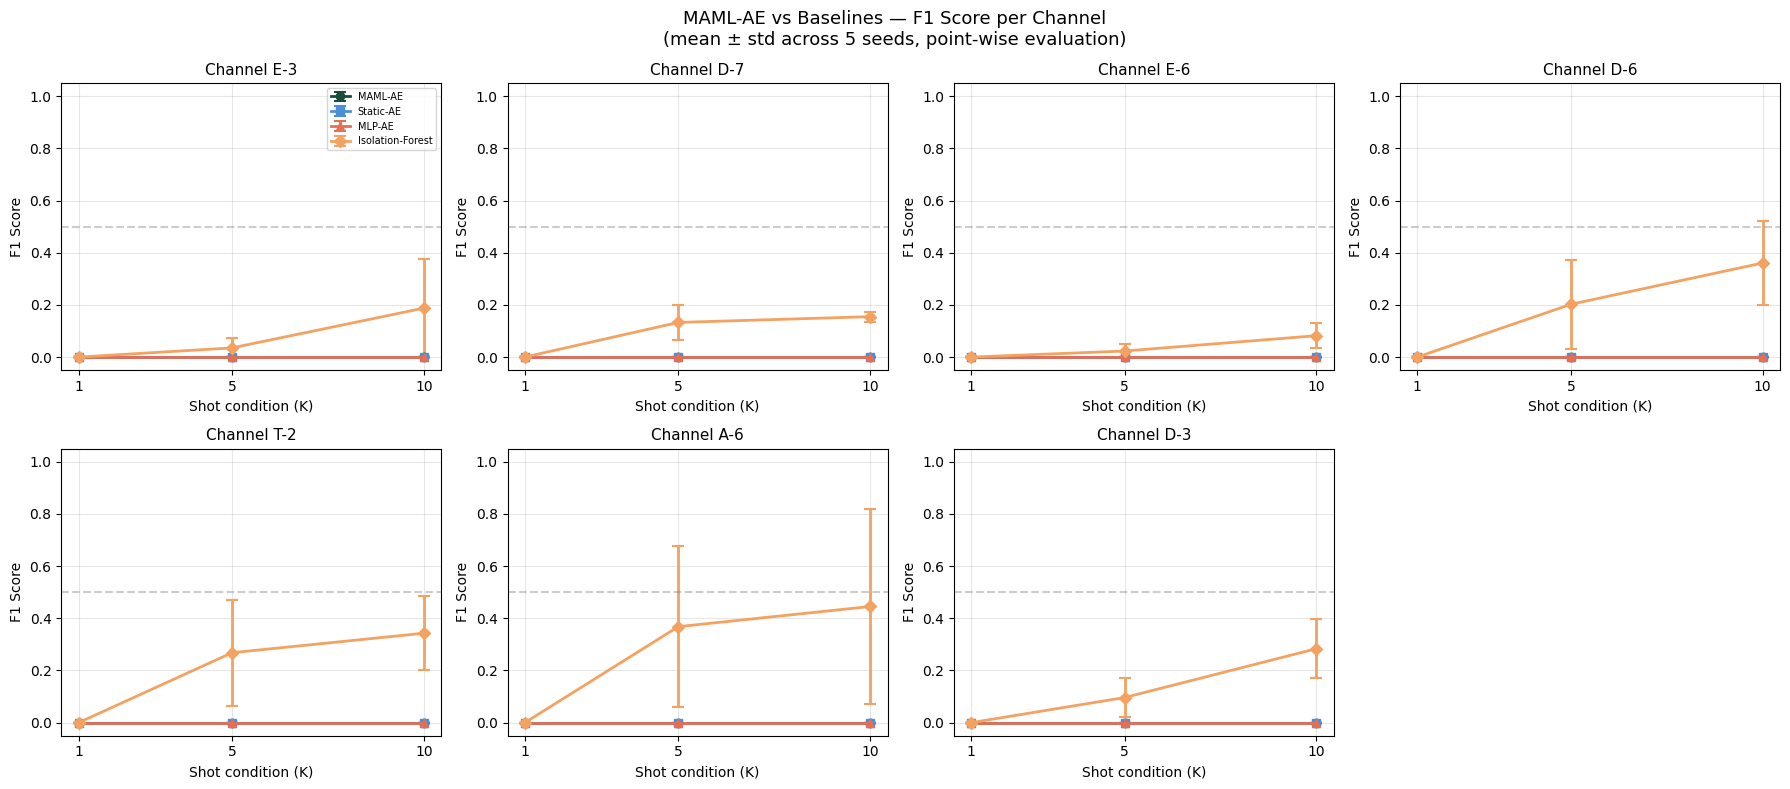

✅ Plot 1 saved


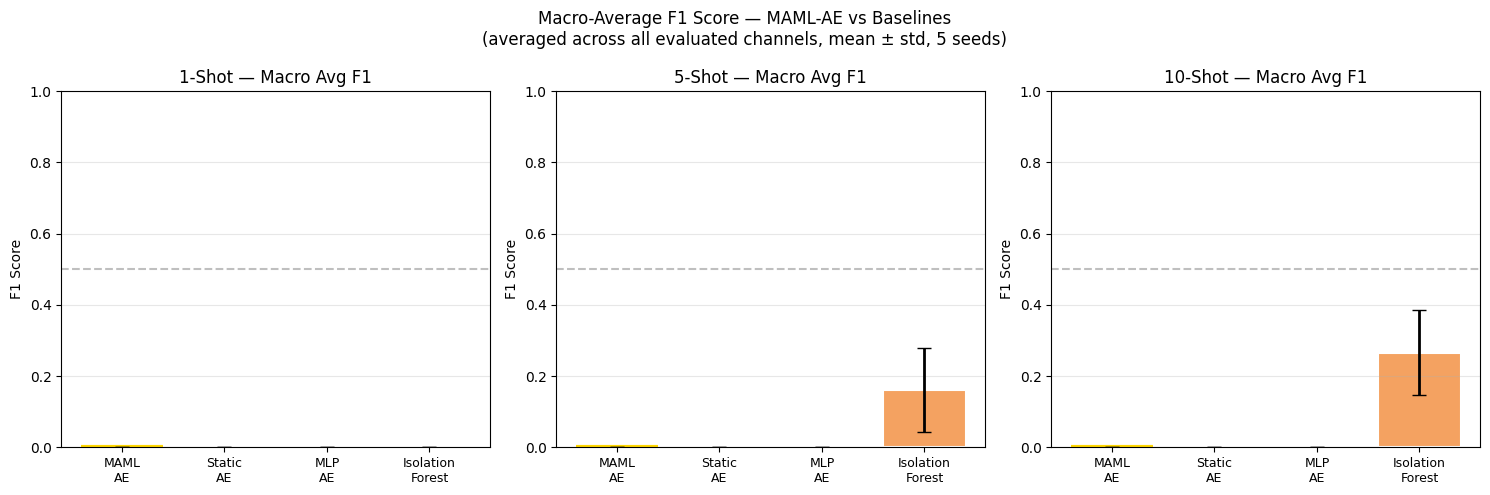

✅ Plot 2 saved


In [14]:
import matplotlib.pyplot as plt

colors = {
    'MAML-AE'          : '#1B4D3E',
    'Static-AE'        : '#4A90D9',
    'MLP-AE'           : '#E76F51',
    'Isolation-Forest' : '#F4A261'
}
markers = {
    'MAML-AE'          : 'o',
    'Static-AE'        : 's',
    'MLP-AE'           : '^',
    'Isolation-Forest' : 'D'
}

# Plot 1 — F1 vs Shot Condition per Channel
fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharey=False)
axes = axes.flatten()

for i, channel_id in enumerate(EVAL_CHANNELS):
    ax = axes[i]
    for method in METHODS:
        f1_means = [
            summary[channel_id][k][method]['f1']['mean']  # ← fixed
            for k in K_SHOTS]
        f1_stds  = [
            summary[channel_id][k][method]['f1']['std']   # ← fixed
            for k in K_SHOTS]
        ax.errorbar(
            K_SHOTS, f1_means, yerr=f1_stds,
            label=method,
            color=colors[method],
            marker=markers[method],
            linewidth=2, markersize=6,
            capsize=4, capthick=1.5)

    ax.set_title(f"Channel {channel_id}", fontsize=11)
    ax.set_xlabel("Shot condition (K)")
    ax.set_ylabel("F1 Score")
    ax.set_xticks(K_SHOTS)
    ax.set_ylim(-0.05, 1.05)
    ax.axhline(y=0.5, color='gray',
               linestyle='--', alpha=0.4)
    ax.grid(True, alpha=0.3)
    if i == 0:
        ax.legend(fontsize=7, loc='upper right')

for j in range(len(EVAL_CHANNELS), len(axes)):
    axes[j].set_visible(False)

plt.suptitle(
    "MAML-AE vs Baselines — F1 Score per Channel\n"
    "(mean ± std across 5 seeds, point-wise evaluation)",
    fontsize=13)
plt.tight_layout()
plt.savefig(f"{OUTPUT_PATH}/results/f1_per_channel.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot 1 saved")

# Plot 2 — Aggregate F1 bar chart
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, k_shot in enumerate(K_SHOTS):
    ax = axes[idx]
    method_f1s  = []
    method_stds = []

    for method in METHODS:
        all_f1s = [
            summary[ch][k_shot][method]['f1']['mean']  # ← fixed
            for ch in EVAL_CHANNELS]
        method_f1s.append(np.mean(all_f1s))
        method_stds.append(np.std(all_f1s))

    bar_colors = [colors[m] for m in METHODS]
    bars = ax.bar(range(len(METHODS)), method_f1s,
                  yerr=method_stds,
                  color=bar_colors,
                  edgecolor='white',
                  linewidth=1.5,
                  capsize=5,
                  error_kw={'linewidth': 2})

    bars[0].set_edgecolor('gold')
    bars[0].set_linewidth(3)

    method_labels = [m.replace('-', '\n') for m in METHODS]
    ax.set_title(f"{k_shot}-Shot — Macro Avg F1", fontsize=12)
    ax.set_xticks(range(len(METHODS)))
    ax.set_xticklabels(method_labels, fontsize=9)
    ax.set_ylabel("F1 Score")
    ax.set_ylim(0, 1.0)
    ax.grid(True, alpha=0.3, axis='y')
    ax.axhline(y=0.5, color='gray',
               linestyle='--', alpha=0.5)

plt.suptitle(
    "Macro-Average F1 Score — MAML-AE vs Baselines\n"
    "(averaged across all evaluated channels, "
    "mean ± std, 5 seeds)",
    fontsize=12)
plt.tight_layout()
plt.savefig(f"{OUTPUT_PATH}/results/aggregate_f1.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot 2 saved")

# Cell 13 — Save All Outputs

In [15]:
import datetime

thesis_summary = {
    'evaluation_date'    : str(datetime.datetime.now()),
    'dataset'            : 'SMAP NASA Spacecraft Telemetry',
    'model'              : 'MAML-AE (LSTM Autoencoder + FOMAML)',
    'training_steps'     : checkpoint['step'],
    'evaluated_channels' : EVAL_CHANNELS,
    'excluded_channels'  : {
        'P-4'  : 'Sensor dropout anomaly — fundamental limitation',
        'D-12' : 'Insufficient normal windows'
    },
    'shot_conditions'    : K_SHOTS,
    'n_seeds'            : N_SEEDS,
    'seeds'              : SEEDS,
    'threshold_method'   : 'Unsupervised — mean + 2*std (1-shot: mean * 1.20)',
    'evaluation_type'    : 'Point-wise — no point-adjust',
    'results'            : summary
}

with open(f"{OUTPUT_PATH}/results/thesis_results.json", "w") as f:
    json.dump(thesis_summary, f, indent=2)

print("=" * 55)
print("NOTEBOOK 5 — EVALUATION COMPLETE")
print("=" * 55)
print()
print("Files saved to /kaggle/working/results/:")
print("  all_results_raw.json    — full per-seed results")
print("  summary.json            — mean ± std per combination")
print("  thesis_results.json     — complete thesis summary")
print("  f1_per_channel.png      — F1 per channel plots")
print("  aggregate_f1.png        — bar chart comparison")
print()
print("IMPORTANT: Click Save Version to preserve all outputs")
print()
print("These numbers are your Objective 2 formal results.")

NOTEBOOK 5 — EVALUATION COMPLETE

Files saved to /kaggle/working/results/:
  all_results_raw.json    — full per-seed results
  summary.json            — mean ± std per combination
  thesis_results.json     — complete thesis summary
  f1_per_channel.png      — F1 per channel plots
  aggregate_f1.png        — bar chart comparison

IMPORTANT: Click Save Version to preserve all outputs

These numbers are your Objective 2 formal results.
